In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# Read and clean df

In [2]:
df = pd.read_csv("grades.csv")

In [3]:
df = df.rename(columns={"race/ethnicity": "race", "parental level of education": "parent_education", 
                        "test preparation course": "test_course", "math score": "math", "reading score": "reading", "writing score": "writing"})

In [4]:
categorics = ["race", "gender", "parent_education", "lunch", "test_course"]

for col in categorics:
    df[col] = pd.Categorical(df[col])

df["parent_education"] = pd.Categorical(df["parent_education"], ordered=True,
                                         categories=["some high school", "high school", "some college", "associate's degree", "bachelor's degree", "master's degree"])

# Simple EDA of math score

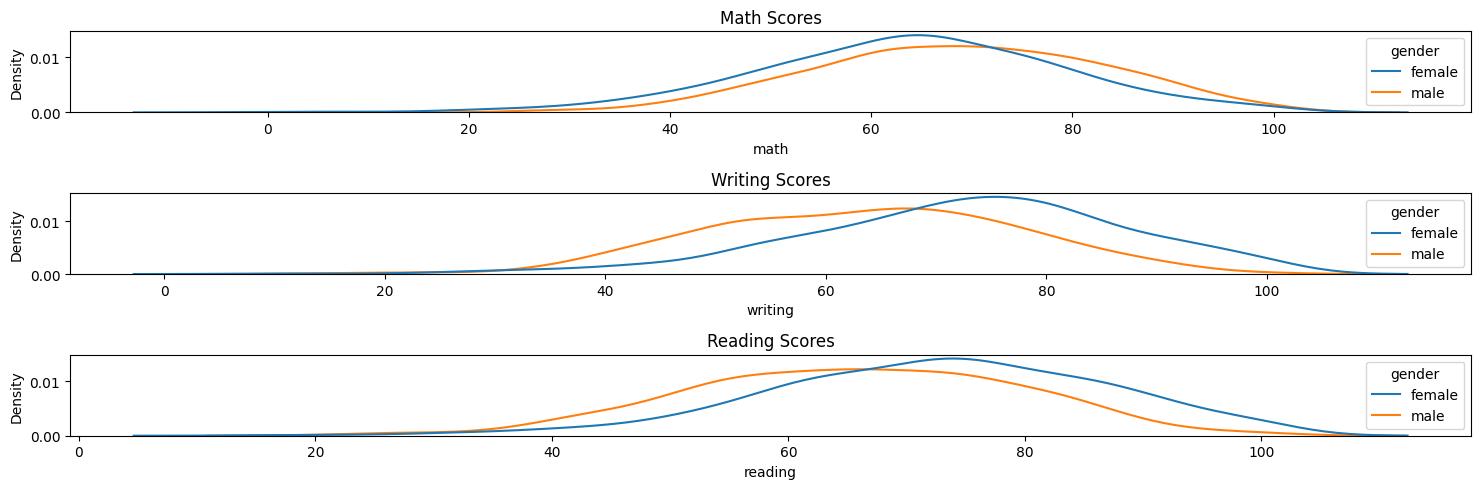

In [5]:
plt.figure(figsize=(15, 5))

# First plot
plt.subplot(3, 1, 1)
sns.kdeplot(data=df, x="math", hue="gender")
plt.title("Math Scores")

# Second plot
plt.subplot(3, 1, 2)
sns.kdeplot(data=df, x="writing", hue="gender")
plt.title("Writing Scores")

# Third plot
plt.subplot(3, 1, 3)
sns.kdeplot(data=df, x="reading", hue="gender")
plt.title("Reading Scores")

plt.tight_layout()
plt.show()

<Axes: xlabel='parent_education', ylabel='math'>

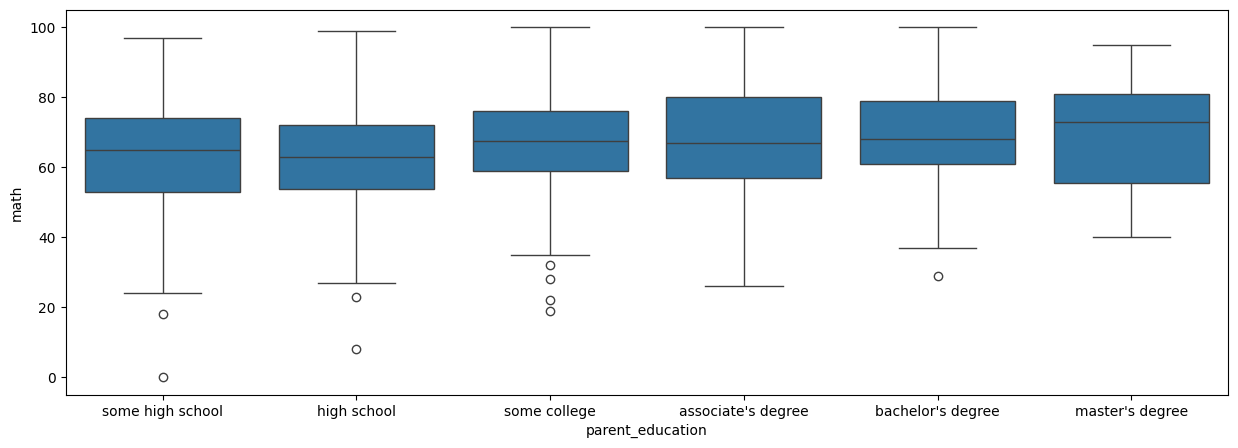

In [6]:
plt.figure(figsize=(15, 5))
sns.boxplot(data=df.sort_values("math", ascending=False),
            y="math",
            x="parent_education")

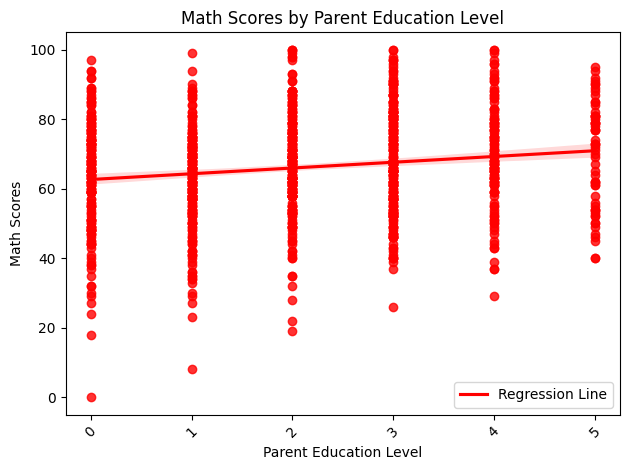

In [7]:
# Convert ordered categorical variable to numerical for regression
df["parent_education_num"] = df["parent_education"].cat.codes
plt.title("Math Scores by Parent Education Level")
sns.regplot(data=df, x="parent_education_num", y="math", scatter=True, color='red', line_kws={"label": "Regression Line"})
plt.xlabel("Parent Education Level")
plt.ylabel("Math Scores")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='lunch', ylabel='math'>

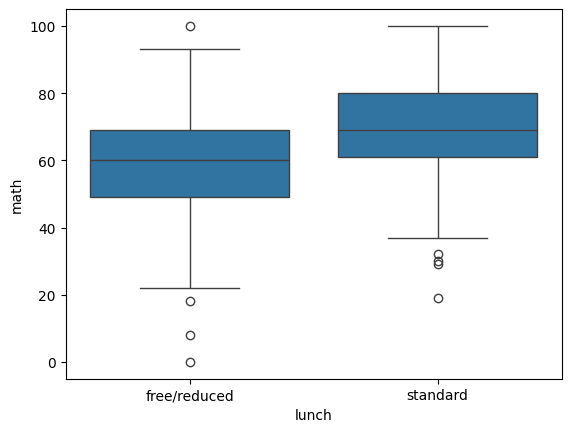

In [8]:
sns.boxplot(data=df, x="lunch", y="math")

<Axes: xlabel='test_course', ylabel='math'>

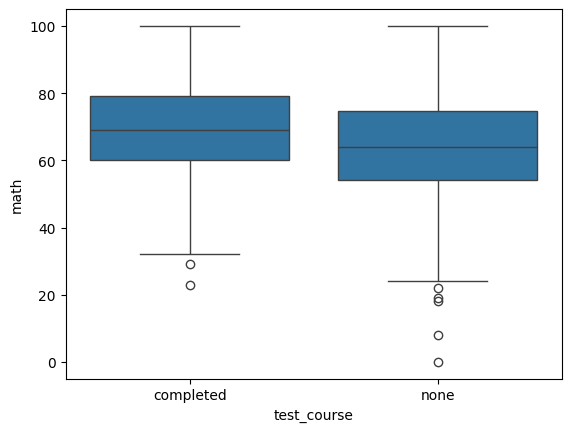

In [9]:
sns.boxplot(data=df, x="test_course", y="math")

In [10]:
# Refine dataframe to include only relevant columns for regression

df_dummies = pd.get_dummies(df, columns=categorics, drop_first=True, dtype=int).copy()

<Axes: >

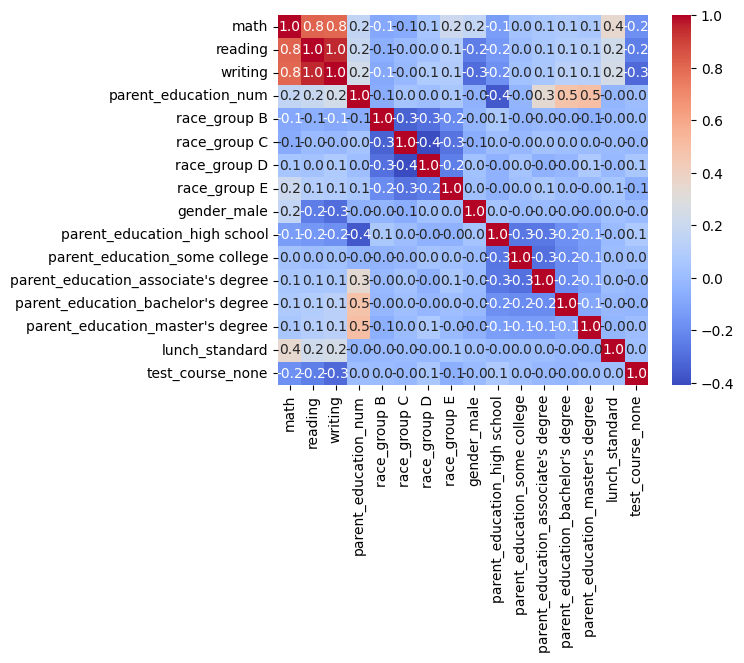

In [11]:
sns.heatmap(df_dummies.corr(), annot=True, fmt=".1f", cmap="coolwarm", square=True)

In [12]:
# Split into train and test sets
from sklearn.model_selection import train_test_split
X = sm.add_constant(df_dummies.drop(columns=["math", "reading", "writing"]))
y = df_dummies["math"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Fit a linear regression model
OLS = sm.OLS(y_train, X_train).fit()
print(OLS.summary())

                            OLS Regression Results                            
Dep. Variable:                   math   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     23.84
Date:                Sun, 27 Jul 2025   Prob (F-statistic):           1.17e-45
Time:                        11:56:07   Log-Likelihood:                -3178.4
No. Observations:                 800   AIC:                             6383.
Df Residuals:                     787   BIC:                             6444.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
co

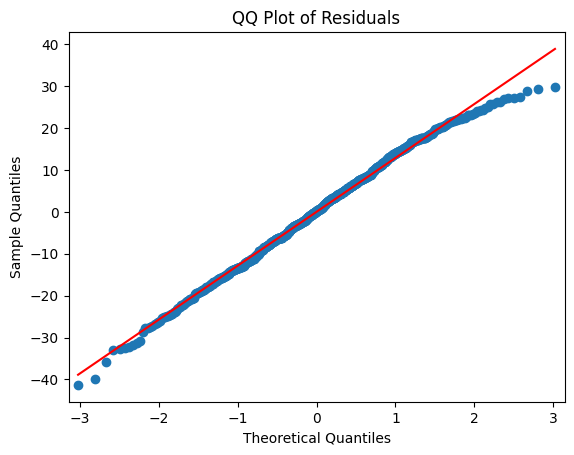

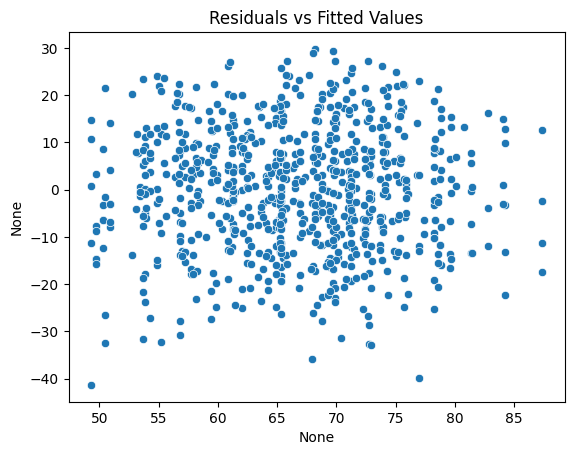

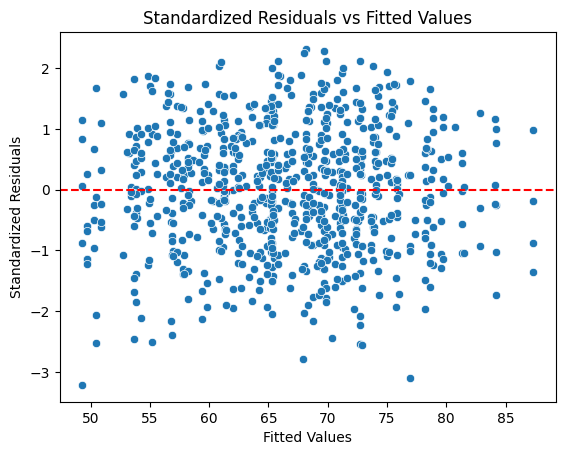

In [17]:
## Assess OLS model fit
sm.qqplot(OLS.resid, line='s')
plt.title("QQ Plot of Residuals")
plt.show()

# Plot residuals against fitted values
plt.title("Residuals vs Fitted Values")
sns.scatterplot(x=OLS.fittedvalues, y=OLS.resid)
plt.show()

# Plot standardized residuals against fitted values
plt.title("Standardized Residuals vs Fitted Values")
sns.scatterplot(x=OLS.fittedvalues, y=stats.zscore(OLS.resid))
plt.axhline(0, linestyle='--', color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Standardized Residuals")
plt.show()

In [15]:
## Evaluate OLS metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
OLS_preds = OLS.predict(X_test)
print(f"Mean Squared Error: {mean_squared_error(y_test, OLS_preds)}, R^2: {r2_score(y_test, OLS_preds)}, Mean Absolute Error: {mean_absolute_error(y_test, OLS_preds)}")

Mean Squared Error: 200.51084564367207, R^2: 0.17599998338251555, Mean Absolute Error: 11.2698727752776


In [16]:
# Fit an LightGBM model
import lightgbm as lgb
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_params = {
    'objective': 'regression',
    'metric': 'mse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}
lgb_model = lgb.train(lgb_params, lgb_train, num_boost_round=100)
# Evaluate LightGBM model
lgb_preds = lgb_model.predict(X_test)
print(f"LightGBM Mean Squared Error: {mean_squared_error(y_test, lgb_preds)}, R^2: {r2_score(y_test, lgb_preds)}, Mean Absolute Error: {mean_absolute_error(y_test, lgb_preds)}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000191 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 13
[LightGBM] [Info] Start training from score 66.496250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai